In [15]:
# =========================
# ECGR 4106 Homework 4
# Name: Samantha Gonzalez
# Student ID: 801353957
# Transformer Models
# =========================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
import time
import math
import os
import re
import urllib.request

import nltk
nltk.download("punkt")
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("results", exist_ok=True)

Using device: cuda
GPU: NVIDIA L4


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [16]:
# =========================
# General Helper Functions
# =========================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    total_size = 0
    for param in model.parameters():
        total_size += param.nelement() * param.element_size()
    return total_size / (1024 ** 2)


def save_dataframe(df, filename):
    path = os.path.join("results", filename)
    df.to_csv(path, index=False)
    print("Saved:", path)

In [17]:
# =========================
# Problem 1 Text Sequence
# =========================

problem1_text = """
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.
"""

print("Problem 1 text length:", len(problem1_text))

Problem 1 text length: 2393


In [18]:
# =========================
# Character Dataset and Transformer Model
# =========================

class CharacterDataset(Dataset):
    def __init__(self, text, seq_length):
        self.seq_length = seq_length
        self.chars = sorted(list(set(text)))
        self.char_to_idx = {ch: i for i, ch in enumerate(self.chars)}
        self.idx_to_char = {i: ch for ch, i in self.char_to_idx.items()}

        self.data = torch.tensor(
            [self.char_to_idx[ch] for ch in text],
            dtype=torch.long
        )

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+1:idx+self.seq_length+1]
        return x, y


class CharTransformer(nn.Module):
    def __init__(self, vocab_size, seq_length, d_model=128, num_heads=4, num_layers=2, dropout=0.1):
        super(CharTransformer, self).__init__()

        self.seq_length = seq_length
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_length, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.shape

        positions = torch.arange(0, seq_len).unsqueeze(0).repeat(batch_size, 1).to(device)

        x = self.token_embedding(x) + self.position_embedding(positions)

        # This mask stops the model from looking ahead
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(device)

        out = self.transformer(x, mask=mask)
        out = self.fc(out)

        return out

In [19]:
# =========================
# Character Training Functions
# =========================

def train_char_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            y.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_char_model(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            loss = criterion(
                outputs.reshape(-1, outputs.shape[-1]),
                y.reshape(-1)
            )

            total_loss += loss.item()

            predictions = torch.argmax(outputs, dim=-1)

            correct += (predictions == y).sum().item()
            total += y.numel()

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def approximate_transformer_complexity(seq_len, d_model, num_layers):
    # Simple comparison estimate
    return num_layers * ((seq_len ** 2) * d_model + seq_len * (d_model ** 2))

In [20]:
# =========================
# Problem 1 Experiments
# =========================

P1_SEQ_LENGTHS = [10, 20, 30]

P1_BATCH_SIZE = 32
P1_EPOCHS = 25
P1_LEARNING_RATE = 0.003

P1_D_MODEL = 128
P1_HEADS = 4
P1_LAYERS = 2

problem1_results = []

for seq_len in P1_SEQ_LENGTHS:
    dataset = CharacterDataset(problem1_text, seq_len)
    vocab_size = len(dataset.chars)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_dataset, batch_size=P1_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=P1_BATCH_SIZE, shuffle=False)

    model = CharTransformer(
        vocab_size=vocab_size,
        seq_length=seq_len,
        d_model=P1_D_MODEL,
        num_heads=P1_HEADS,
        num_layers=P1_LAYERS
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=P1_LEARNING_RATE)

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    print("\n====================================")
    print("Problem 1 Transformer | Seq Length:", seq_len)
    print("====================================")

    for epoch in range(P1_EPOCHS):
        train_loss = train_char_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = validate_char_model(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch+1:02d}/{P1_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    total_time = time.time() - start_time

    problem1_results.append({
        "model": "Transformer",
        "sequence_length": seq_len,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_accuracy": val_accuracies[-1],
        "training_time_sec": total_time,
        "parameters": count_parameters(model),
        "model_size_mb": model_size_mb(model),
        "approx_complexity": approximate_transformer_complexity(seq_len, P1_D_MODEL, P1_LAYERS)
    })

problem1_df = pd.DataFrame(problem1_results)
save_dataframe(problem1_df, "problem1_transformer_results.csv")
problem1_df


Problem 1 Transformer | Seq Length: 10
Epoch 01/25 | Train Loss: 2.4465 | Val Loss: 1.9826 | Val Acc: 42.77%
Epoch 02/25 | Train Loss: 1.8353 | Val Loss: 1.6129 | Val Acc: 50.73%
Epoch 03/25 | Train Loss: 1.5663 | Val Loss: 1.4203 | Val Acc: 57.21%
Epoch 04/25 | Train Loss: 1.4070 | Val Loss: 1.2638 | Val Acc: 60.29%
Epoch 05/25 | Train Loss: 1.2588 | Val Loss: 1.1546 | Val Acc: 64.00%
Epoch 06/25 | Train Loss: 1.1891 | Val Loss: 1.0956 | Val Acc: 64.65%
Epoch 07/25 | Train Loss: 1.1009 | Val Loss: 1.0299 | Val Acc: 67.04%
Epoch 08/25 | Train Loss: 1.0561 | Val Loss: 0.9779 | Val Acc: 68.76%
Epoch 09/25 | Train Loss: 1.0031 | Val Loss: 0.9550 | Val Acc: 69.96%
Epoch 10/25 | Train Loss: 0.9503 | Val Loss: 0.9143 | Val Acc: 70.34%
Epoch 11/25 | Train Loss: 0.9351 | Val Loss: 0.8847 | Val Acc: 71.66%
Epoch 12/25 | Train Loss: 0.9040 | Val Loss: 0.8521 | Val Acc: 72.29%
Epoch 13/25 | Train Loss: 0.8719 | Val Loss: 0.8381 | Val Acc: 72.96%
Epoch 14/25 | Train Loss: 0.8425 | Val Loss: 0.814

,model,sequence_length,final_train_loss,final_val_loss,final_val_accuracy,training_time_sec,parameters,model_size_mb,approx_complexity
0,Transformer,10,0.727324,0.749062,76.163522,11.093336,409389,1.561695,353280
1,Transformer,20,0.404396,0.388453,87.326316,11.098984,410669,1.566578,757760
2,Transformer,30,0.300499,0.254068,91.719521,10.876814,411949,1.571461,1213440


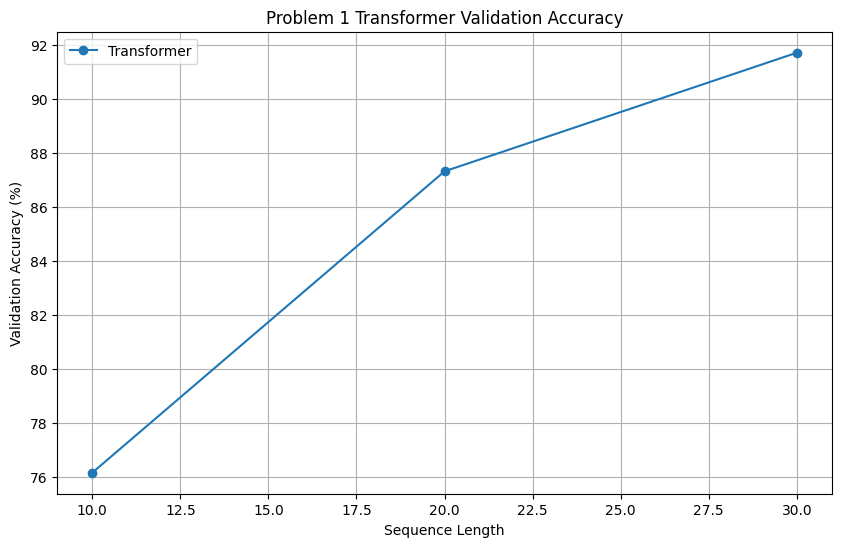

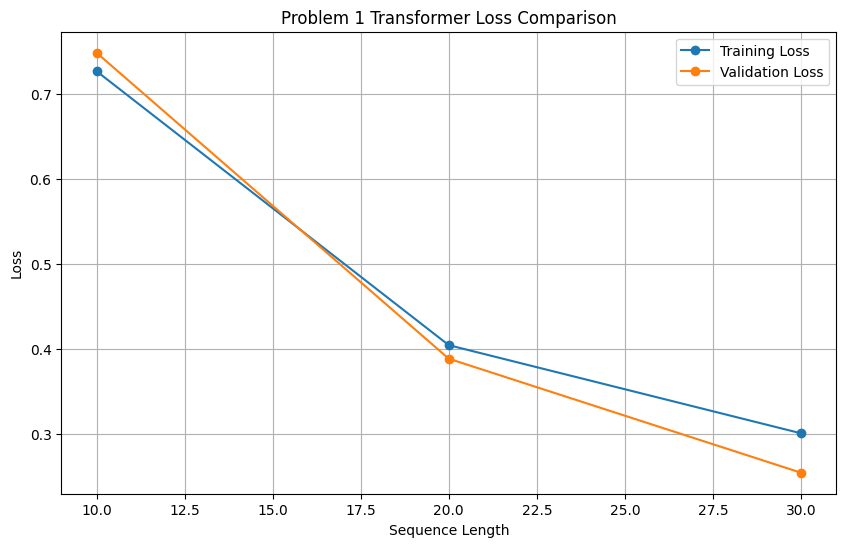

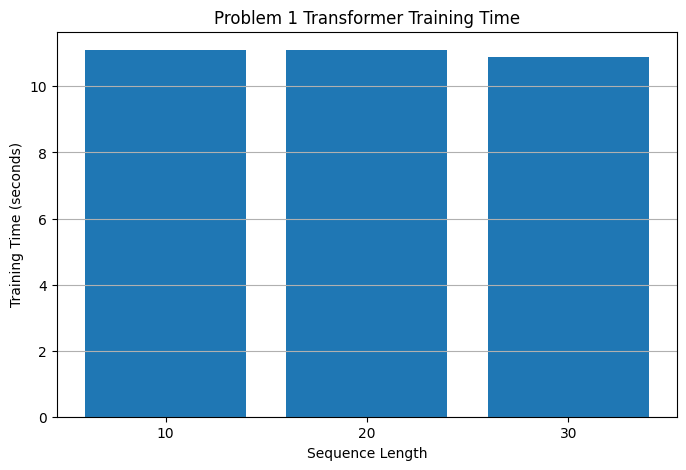

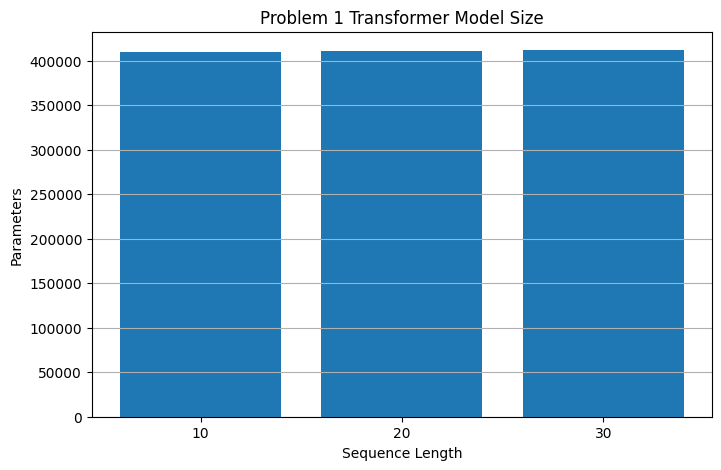

In [21]:
# =========================
# Problem 1 Plots
# =========================

plt.figure(figsize=(10, 6))
plt.plot(problem1_df["sequence_length"], problem1_df["final_val_accuracy"], marker="o", label="Transformer")
plt.xlabel("Sequence Length")
plt.ylabel("Validation Accuracy (%)")
plt.title("Problem 1 Transformer Validation Accuracy")
plt.grid(True)
plt.legend()
plt.savefig("results/problem1_transformer_validation_accuracy.png")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(problem1_df["sequence_length"], problem1_df["final_train_loss"], marker="o", label="Training Loss")
plt.plot(problem1_df["sequence_length"], problem1_df["final_val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Sequence Length")
plt.ylabel("Loss")
plt.title("Problem 1 Transformer Loss Comparison")
plt.grid(True)
plt.legend()
plt.savefig("results/problem1_transformer_loss_comparison.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(problem1_df["sequence_length"].astype(str), problem1_df["training_time_sec"])
plt.xlabel("Sequence Length")
plt.ylabel("Training Time (seconds)")
plt.title("Problem 1 Transformer Training Time")
plt.grid(axis="y")
plt.savefig("results/problem1_transformer_training_time.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(problem1_df["sequence_length"].astype(str), problem1_df["parameters"])
plt.xlabel("Sequence Length")
plt.ylabel("Parameters")
plt.title("Problem 1 Transformer Model Size")
plt.grid(axis="y")
plt.savefig("results/problem1_transformer_model_size.png")
plt.show()

In [22]:
# =========================
# Problem 2 Tiny Shakespeare Dataset
# =========================

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "tinyshakespeare.txt"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

with open(filename, "r", encoding="utf-8") as f:
    shakespeare_text = f.read()

# Use part of the dataset to keep training reasonable
shakespeare_text = shakespeare_text[:200000]

print("Tiny Shakespeare text length:", len(shakespeare_text))
print(shakespeare_text[:300])

Tiny Shakespeare text length: 200000
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [23]:
# =========================
# Text Generation Function
# =========================

def generate_char_text(model, dataset, start_text="To be", length=200):
    model.eval()

    chars = list(start_text)

    with torch.no_grad():
        for _ in range(length):
            input_chars = chars[-dataset.seq_length:]

            input_ids = torch.tensor(
                [[dataset.char_to_idx.get(ch, 0) for ch in input_chars]],
                dtype=torch.long
            ).to(device)

            if input_ids.shape[1] < dataset.seq_length:
                pad_len = dataset.seq_length - input_ids.shape[1]
                padding = torch.zeros((1, pad_len), dtype=torch.long).to(device)
                input_ids = torch.cat((padding, input_ids), dim=1)

            output = model(input_ids)
            last_output = output[:, -1, :]

            probabilities = torch.softmax(last_output, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1).item()

            next_char = dataset.idx_to_char[next_id]
            chars.append(next_char)

    return "".join(chars)

In [24]:
# =========================
# Problem 2 Basic Transformer Experiments
# =========================

P2_SEQ_LENGTHS = [20, 30]

P2_BATCH_SIZE = 64
P2_EPOCHS = 10
P2_LEARNING_RATE = 0.003

problem2_results = []

for seq_len in P2_SEQ_LENGTHS:
    dataset = CharacterDataset(shakespeare_text, seq_len)
    vocab_size = len(dataset.chars)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_dataset, batch_size=P2_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=P2_BATCH_SIZE, shuffle=False)

    model = CharTransformer(
        vocab_size=vocab_size,
        seq_length=seq_len,
        d_model=128,
        num_heads=2,
        num_layers=2
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=P2_LEARNING_RATE)

    train_losses = []
    val_losses = []
    val_accuracies = []

    print("\n====================================")
    print("Problem 2 Transformer | Seq Length:", seq_len)
    print("====================================")

    start_time = time.time()

    for epoch in range(P2_EPOCHS):
        train_loss = train_char_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = validate_char_model(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch+1:02d}/{P2_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    total_time = time.time() - start_time

    generated_text = generate_char_text(model, dataset, start_text="To be", length=200)

    problem2_results.append({
        "model": "Transformer",
        "sequence_length": seq_len,
        "blocks": 2,
        "heads": 2,
        "hidden_size": 128,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_accuracy": val_accuracies[-1],
        "training_time_sec": total_time,
        "parameters": count_parameters(model),
        "model_size_mb": model_size_mb(model),
        "perplexity": math.exp(val_losses[-1]),
        "generated_text": generated_text
    })

problem2_df = pd.DataFrame(problem2_results)
save_dataframe(problem2_df, "problem2_basic_transformer_results.csv")
problem2_df


Problem 2 Transformer | Seq Length: 20
Epoch 01/10 | Train Loss: 1.8044 | Val Loss: 1.5840 | Val Acc: 51.47%
Epoch 02/10 | Train Loss: 1.6410 | Val Loss: 1.5202 | Val Acc: 52.82%
Epoch 03/10 | Train Loss: 1.6031 | Val Loss: 1.4924 | Val Acc: 53.56%
Epoch 04/10 | Train Loss: 1.5824 | Val Loss: 1.4671 | Val Acc: 54.23%
Epoch 05/10 | Train Loss: 1.5670 | Val Loss: 1.4535 | Val Acc: 54.60%
Epoch 06/10 | Train Loss: 1.5537 | Val Loss: 1.4427 | Val Acc: 54.72%
Epoch 07/10 | Train Loss: 1.5466 | Val Loss: 1.4298 | Val Acc: 55.27%
Epoch 08/10 | Train Loss: 1.5376 | Val Loss: 1.4242 | Val Acc: 55.33%
Epoch 09/10 | Train Loss: 1.5318 | Val Loss: 1.4127 | Val Acc: 55.69%
Epoch 10/10 | Train Loss: 1.5255 | Val Loss: 1.4083 | Val Acc: 55.78%

Problem 2 Transformer | Seq Length: 30
Epoch 01/10 | Train Loss: 1.7496 | Val Loss: 1.5132 | Val Acc: 53.15%
Epoch 02/10 | Train Loss: 1.5802 | Val Loss: 1.4471 | Val Acc: 54.84%
Epoch 03/10 | Train Loss: 1.5440 | Val Loss: 1.4180 | Val Acc: 55.57%
Epoch 04/1

,model,sequence_length,blocks,heads,hidden_size,final_train_loss,final_val_loss,final_val_accuracy,training_time_sec,parameters,model_size_mb,perplexity,generated_text
0,Transformer,20,2,2,128,1.525494,1.408270,55.781578,188.585846,415038,1.583244,4.088877,To behold:\nIs thy viction.\n\nMENENIUS:\nI un...
1,Transformer,30,2,2,128,1.473563,1.340028,57.627727,188.328933,416318,1.588127,3.819151,To be OUCESTER:\nDo to thy scatch dead betide ...


In [25]:
# =========================
# Problem 2 Hyperparameter Experiments
# =========================

# First six cover 1, 2, and 4 blocks with 2 and 4 heads.
# Last two also test hidden size changes.
p2_hyper_configs = [
    {"blocks": 1, "heads": 2, "hidden_size": 128},
    {"blocks": 1, "heads": 4, "hidden_size": 128},
    {"blocks": 2, "heads": 2, "hidden_size": 128},
    {"blocks": 2, "heads": 4, "hidden_size": 128},
    {"blocks": 4, "heads": 2, "hidden_size": 128},
    {"blocks": 4, "heads": 4, "hidden_size": 128},
    {"blocks": 2, "heads": 2, "hidden_size": 64},
    {"blocks": 2, "heads": 4, "hidden_size": 256},
]

P2_HYPER_SEQ_LEN = 30
P2_HYPER_EPOCHS = 8

dataset = CharacterDataset(shakespeare_text, P2_HYPER_SEQ_LEN)
vocab_size = len(dataset.chars)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=P2_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=P2_BATCH_SIZE, shuffle=False)

problem2_hyper_results = []

for config in p2_hyper_configs:
    blocks = config["blocks"]
    heads = config["heads"]
    hidden_size = config["hidden_size"]

    print("\n====================================")
    print(f"Problem 2 Hyperparameter Test | Blocks={blocks}, Heads={heads}, Hidden={hidden_size}")
    print("====================================")

    model = CharTransformer(
        vocab_size=vocab_size,
        seq_length=P2_HYPER_SEQ_LEN,
        d_model=hidden_size,
        num_heads=heads,
        num_layers=blocks
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=P2_LEARNING_RATE)

    start_time = time.time()

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(P2_HYPER_EPOCHS):
        train_loss = train_char_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = validate_char_model(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch+1:02d}/{P2_HYPER_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    inference_start = time.time()
    generated_text = generate_char_text(model, dataset, start_text="To be", length=200)
    inference_time = time.time() - inference_start

    problem2_hyper_results.append({
        "blocks": blocks,
        "heads": heads,
        "hidden_size": hidden_size,
        "sequence_length": P2_HYPER_SEQ_LEN,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_accuracy": val_accuracies[-1],
        "training_time_sec": training_time,
        "inference_time_sec": inference_time,
        "parameters": count_parameters(model),
        "model_size_mb": model_size_mb(model),
        "perplexity": math.exp(val_losses[-1]),
        "generated_text": generated_text
    })

problem2_hyper_df = pd.DataFrame(problem2_hyper_results)
save_dataframe(problem2_hyper_df, "problem2_hyperparameter_results.csv")
problem2_hyper_df


Problem 2 Hyperparameter Test | Blocks=1, Heads=2, Hidden=128
Epoch 01/8 | Train Loss: 1.8491 | Val Loss: 1.6325 | Val Acc: 49.53%
Epoch 02/8 | Train Loss: 1.7284 | Val Loss: 1.6003 | Val Acc: 50.20%
Epoch 03/8 | Train Loss: 1.7078 | Val Loss: 1.5830 | Val Acc: 50.60%
Epoch 04/8 | Train Loss: 1.6970 | Val Loss: 1.5720 | Val Acc: 50.66%
Epoch 05/8 | Train Loss: 1.6896 | Val Loss: 1.5697 | Val Acc: 50.70%
Epoch 06/8 | Train Loss: 1.6854 | Val Loss: 1.5648 | Val Acc: 50.87%
Epoch 07/8 | Train Loss: 1.6811 | Val Loss: 1.5611 | Val Acc: 50.88%
Epoch 08/8 | Train Loss: 1.6783 | Val Loss: 1.5562 | Val Acc: 50.92%

Problem 2 Hyperparameter Test | Blocks=1, Heads=4, Hidden=128
Epoch 01/8 | Train Loss: 1.7884 | Val Loss: 1.5545 | Val Acc: 52.06%
Epoch 02/8 | Train Loss: 1.6340 | Val Loss: 1.5064 | Val Acc: 53.14%
Epoch 03/8 | Train Loss: 1.6061 | Val Loss: 1.4850 | Val Acc: 53.74%
Epoch 04/8 | Train Loss: 1.5914 | Val Loss: 1.4695 | Val Acc: 54.11%
Epoch 05/8 | Train Loss: 1.5816 | Val Loss: 1.

,blocks,heads,hidden_size,sequence_length,final_train_loss,final_val_loss,final_val_accuracy,training_time_sec,inference_time_sec,parameters,model_size_mb,perplexity,generated_text
0,1,2,128,30,1.678304,1.556199,50.924305,101.396924,0.239788,218046,0.831779,4.740766,"To better his we his himself, him. You not hea..."
1,1,4,128,30,1.565079,1.446261,54.538597,102.096373,0.240419,218046,0.831779,4.247205,"To beseech thou me, at let all fear\nHe's fit ..."
2,2,2,128,30,1.474490,1.344879,57.508460,150.750839,0.333027,416318,1.588127,3.837721,"To becond CORIOLANUS:\nAy, leave, name since f..."
3,2,4,128,30,1.439263,1.310708,58.371589,149.757850,0.330542,416318,1.588127,3.708797,To befer:\n\nVOLUMNIA:\nYou are indeed for thi...
4,4,2,128,30,1.413620,1.298981,58.742228,248.350523,0.495341,812862,3.100822,3.665558,"To beCINIUS:\nAEdiles, &CINIUS:\nBut?\n\nMENEN..."
5,4,4,128,30,1.386733,1.263831,59.660032,247.683284,0.477943,812862,3.100822,3.538954,"To beCKNEENIUS:\nMENENIUS:\nFor your deed,\nAn..."
6,2,2,64,30,1.604029,1.479044,53.869247,150.609827,0.318715,109886,0.419182,4.388747,To becond Citizen:\nTrubt my sneplease your so...
7,2,4,256,30,1.317242,1.149322,62.909270,151.768598,0.322125,1619006,6.176018,3.156052,To berUFirst curse my gafest consider signs th...


In [26]:
# =========================
# Problem 2 Sequence Length 50
# =========================

P2_SEQ50_LEN = 50
P2_SEQ50_EPOCHS = 10

dataset = CharacterDataset(shakespeare_text, P2_SEQ50_LEN)
vocab_size = len(dataset.chars)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=P2_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=P2_BATCH_SIZE, shuffle=False)

model = CharTransformer(
    vocab_size=vocab_size,
    seq_length=P2_SEQ50_LEN,
    d_model=128,
    num_heads=2,
    num_layers=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=P2_LEARNING_RATE)

train_losses = []
val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(P2_SEQ50_EPOCHS):
    train_loss = train_char_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_accuracy = validate_char_model(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{P2_SEQ50_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

training_time = time.time() - start_time

problem2_seq50_df = pd.DataFrame([{
    "model": "Transformer",
    "sequence_length": 50,
    "blocks": 2,
    "heads": 2,
    "hidden_size": 128,
    "final_train_loss": train_losses[-1],
    "final_val_loss": val_losses[-1],
    "final_val_accuracy": val_accuracies[-1],
    "training_time_sec": training_time,
    "parameters": count_parameters(model),
    "model_size_mb": model_size_mb(model),
    "perplexity": math.exp(val_losses[-1])
}])

save_dataframe(problem2_seq50_df, "problem2_seq50_results.csv")
problem2_seq50_df

Epoch 01/10 | Train Loss: 1.6873 | Val Loss: 1.4333 | Val Acc: 55.37%
Epoch 02/10 | Train Loss: 1.5089 | Val Loss: 1.3649 | Val Acc: 57.12%
Epoch 03/10 | Train Loss: 1.4713 | Val Loss: 1.3321 | Val Acc: 57.94%
Epoch 04/10 | Train Loss: 1.4484 | Val Loss: 1.3100 | Val Acc: 58.46%
Epoch 05/10 | Train Loss: 1.4330 | Val Loss: 1.2917 | Val Acc: 59.02%
Epoch 06/10 | Train Loss: 1.4212 | Val Loss: 1.2788 | Val Acc: 59.32%
Epoch 07/10 | Train Loss: 1.4106 | Val Loss: 1.2661 | Val Acc: 59.58%
Epoch 08/10 | Train Loss: 1.4022 | Val Loss: 1.2536 | Val Acc: 60.04%
Epoch 09/10 | Train Loss: 1.3953 | Val Loss: 1.2428 | Val Acc: 60.32%
Epoch 10/10 | Train Loss: 1.3885 | Val Loss: 1.2384 | Val Acc: 60.40%
Saved: results/problem2_seq50_results.csv


,model,sequence_length,blocks,heads,hidden_size,final_train_loss,final_val_loss,final_val_accuracy,training_time_sec,parameters,model_size_mb,perplexity
0,Transformer,50,2,2,128,1.388494,1.238356,60.39855,198.470019,418878,1.597893,3.449937


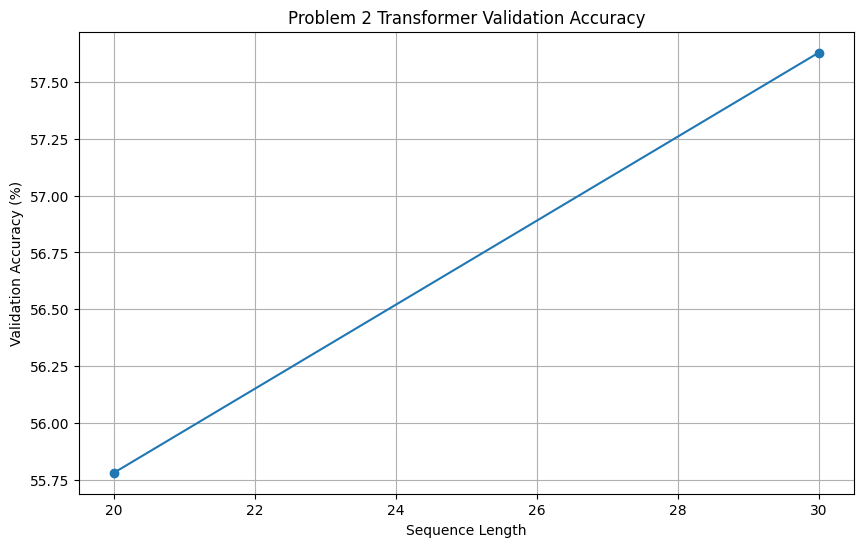

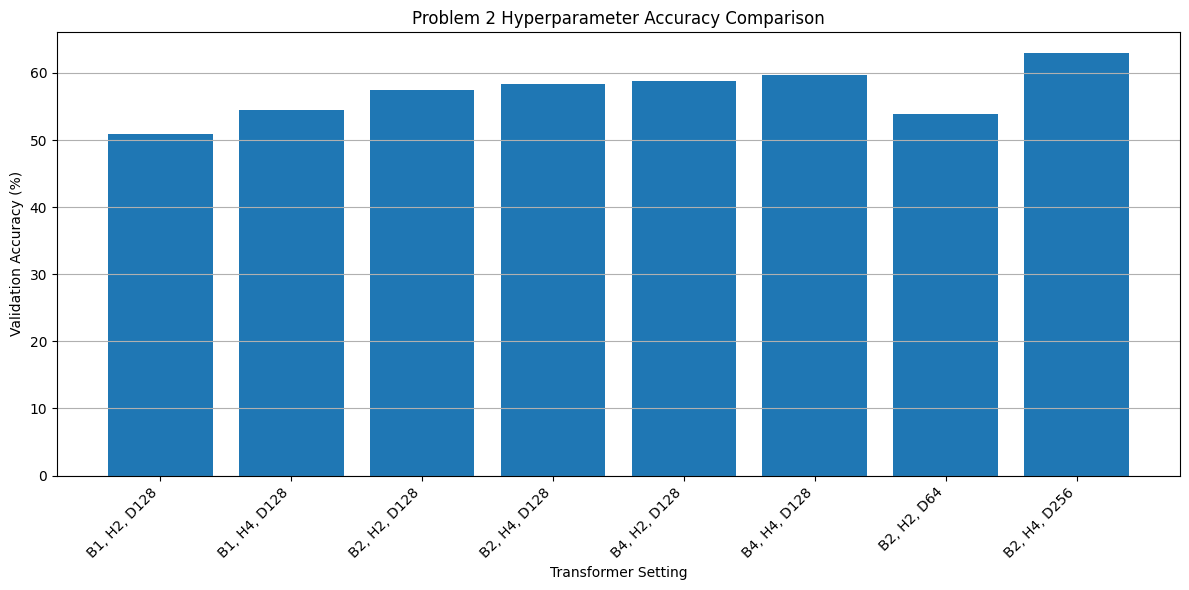

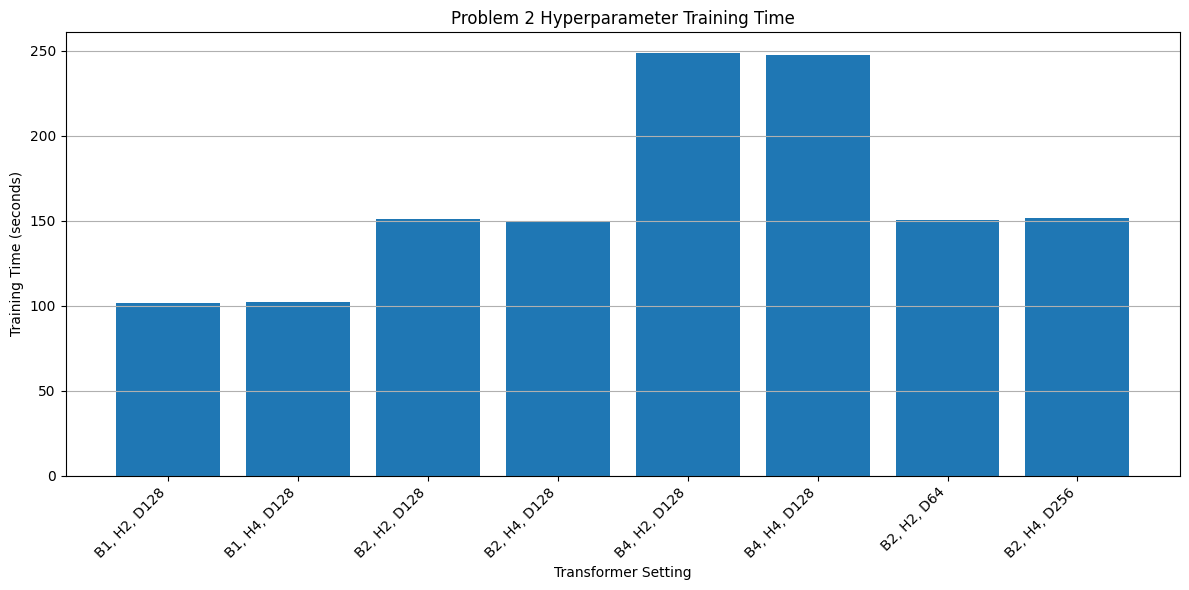

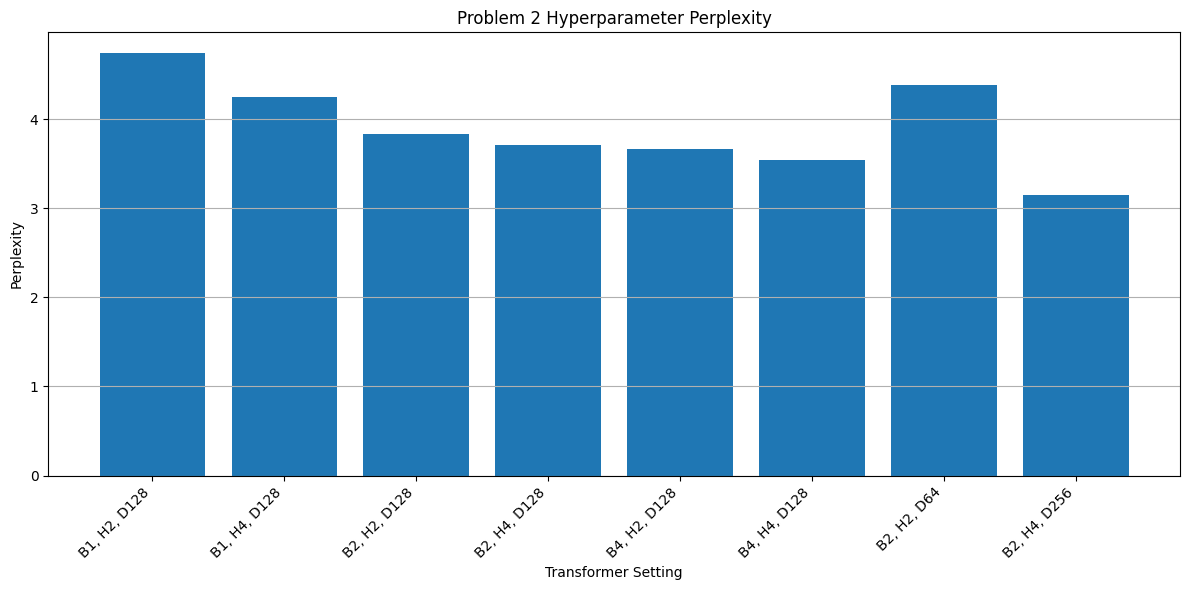

In [27]:
# =========================
# Problem 2 Plots
# =========================

plt.figure(figsize=(10, 6))
plt.plot(problem2_df["sequence_length"], problem2_df["final_val_accuracy"], marker="o")
plt.xlabel("Sequence Length")
plt.ylabel("Validation Accuracy (%)")
plt.title("Problem 2 Transformer Validation Accuracy")
plt.grid(True)
plt.savefig("results/problem2_validation_accuracy.png")
plt.show()

plt.figure(figsize=(12, 6))
labels = [
    f"B{row['blocks']}, H{row['heads']}, D{row['hidden_size']}"
    for _, row in problem2_hyper_df.iterrows()
]
plt.bar(labels, problem2_hyper_df["final_val_accuracy"])
plt.xlabel("Transformer Setting")
plt.ylabel("Validation Accuracy (%)")
plt.title("Problem 2 Hyperparameter Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("results/problem2_hyperparameter_accuracy.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(labels, problem2_hyper_df["training_time_sec"])
plt.xlabel("Transformer Setting")
plt.ylabel("Training Time (seconds)")
plt.title("Problem 2 Hyperparameter Training Time")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("results/problem2_hyperparameter_training_time.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(labels, problem2_hyper_df["perplexity"])
plt.xlabel("Transformer Setting")
plt.ylabel("Perplexity")
plt.title("Problem 2 Hyperparameter Perplexity")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("results/problem2_hyperparameter_perplexity.png")
plt.show()

In [28]:
# =========================
# Problems 3 and 4 Dataset
# =========================

translation_filename = "vast_english_french.txt"

with open(translation_filename, "r", encoding="utf-8") as f:
    lines = f.readlines()

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zA-ZÀ-ÿ?.!,']+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

translation_pairs = []

for line in lines:
    parts = line.strip().split("\t")

    if len(parts) >= 2:
        eng = clean_text(parts[0])
        fra = clean_text(parts[1])

        if len(eng) > 0 and len(fra) > 0:
            translation_pairs.append((eng, fra))

print("Total translation pairs:", len(translation_pairs))

train_pairs, val_pairs = train_test_split(
    translation_pairs,
    test_size=0.2,
    random_state=SEED
)

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Total translation pairs: 555
Train pairs: 444
Validation pairs: 111


In [29]:
# =========================
# Word Vocabulary
# =========================

SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

class WordVocabulary:
    def __init__(self):
        self.word2idx = {
            PAD_TOKEN: 0,
            SOS_TOKEN: 1,
            EOS_TOKEN: 2,
            UNK_TOKEN: 3
        }

        self.idx2word = {
            0: PAD_TOKEN,
            1: SOS_TOKEN,
            2: EOS_TOKEN,
            3: UNK_TOKEN
        }

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def sentence_to_indices(self, sentence, max_len):
        words = sentence.split()
        indices = [self.word2idx.get(word, self.word2idx[UNK_TOKEN]) for word in words]

        indices = [self.word2idx[SOS_TOKEN]] + indices + [self.word2idx[EOS_TOKEN]]

        if len(indices) < max_len:
            indices += [self.word2idx[PAD_TOKEN]] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
            indices[-1] = self.word2idx[EOS_TOKEN]

        return indices

    def indices_to_sentence(self, indices):
        words = []

        for idx in indices:
            word = self.idx2word.get(int(idx), UNK_TOKEN)

            if word == EOS_TOKEN:
                break

            if word not in [SOS_TOKEN, PAD_TOKEN]:
                words.append(word)

        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)


eng_vocab = WordVocabulary()
fra_vocab = WordVocabulary()

for eng, fra in train_pairs:
    eng_vocab.add_sentence(eng)
    fra_vocab.add_sentence(fra)

print("English vocab size:", len(eng_vocab))
print("French vocab size:", len(fra_vocab))

English vocab size: 890
French vocab size: 998


In [30]:
# =========================
# Translation Dataset
# =========================

MAX_TRANSLATION_LEN = 15

class TranslationDataset(Dataset):
    def __init__(self, pairs, source_vocab, target_vocab, max_len=MAX_TRANSLATION_LEN):
        self.pairs = pairs
        self.source_vocab = source_vocab
        self.target_vocab = target_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        source_sentence, target_sentence = self.pairs[idx]

        source = self.source_vocab.sentence_to_indices(source_sentence, self.max_len)
        target = self.target_vocab.sentence_to_indices(target_sentence, self.max_len)

        return torch.tensor(source), torch.tensor(target)


def make_translation_loaders(train_pairs, val_pairs, source_vocab, target_vocab, batch_size=64):
    train_dataset = TranslationDataset(train_pairs, source_vocab, target_vocab)
    val_dataset = TranslationDataset(val_pairs, source_vocab, target_vocab)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [31]:
# =========================
# Transformer Encoder-Decoder
# =========================

class TransformerSeq2Seq(nn.Module):
    def __init__(self, source_vocab_size, target_vocab_size, max_len, d_model=128, num_heads=4, num_layers=2, dropout=0.1):
        super(TransformerSeq2Seq, self).__init__()

        self.d_model = d_model
        self.max_len = max_len

        self.source_embedding = nn.Embedding(source_vocab_size, d_model, padding_idx=0)
        self.target_embedding = nn.Embedding(target_vocab_size, d_model, padding_idx=0)

        self.source_position = nn.Embedding(max_len, d_model)
        self.target_position = nn.Embedding(max_len, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, target_vocab_size)

    def make_target_mask(self, target):
        target_len = target.shape[1]
        mask = torch.triu(torch.ones(target_len, target_len), diagonal=1).bool().to(device)
        return mask

    def forward(self, source, target):
        batch_size = source.shape[0]
        source_len = source.shape[1]
        target_len = target.shape[1]

        source_positions = torch.arange(0, source_len).unsqueeze(0).repeat(batch_size, 1).to(device)
        target_positions = torch.arange(0, target_len).unsqueeze(0).repeat(batch_size, 1).to(device)

        source_embedded = self.source_embedding(source) + self.source_position(source_positions)
        target_embedded = self.target_embedding(target) + self.target_position(target_positions)

        target_mask = self.make_target_mask(target)

        source_padding_mask = source == 0
        target_padding_mask = target == 0

        output = self.transformer(
            source_embedded,
            target_embedded,
            tgt_mask=target_mask,
            src_key_padding_mask=source_padding_mask,
            tgt_key_padding_mask=target_padding_mask
        )

        output = self.fc(output)

        return output

In [32]:
# =========================
# Translation Training and Metrics
# =========================

def train_translation_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for source, target in loader:
        source = source.to(device)
        target = target.to(device)

        target_input = target[:, :-1]
        target_output = target[:, 1:]

        optimizer.zero_grad()

        output = model(source, target_input)

        loss = criterion(
            output.reshape(-1, output.shape[-1]),
            target_output.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_translation_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for source, target in loader:
            source = source.to(device)
            target = target.to(device)

            target_input = target[:, :-1]
            target_output = target[:, 1:]

            output = model(source, target_input)

            loss = criterion(
                output.reshape(-1, output.shape[-1]),
                target_output.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(loader)


def greedy_translate(model, sentence, source_vocab, target_vocab, max_len=MAX_TRANSLATION_LEN):
    model.eval()

    source_indices = source_vocab.sentence_to_indices(sentence, max_len)
    source = torch.tensor(source_indices).unsqueeze(0).to(device)

    target_indices = [target_vocab.word2idx[SOS_TOKEN]]

    with torch.no_grad():
        for _ in range(max_len - 1):
            target = torch.tensor(target_indices).unsqueeze(0).to(device)

            output = model(source, target)
            next_token = output[:, -1, :].argmax(1).item()

            if next_token == target_vocab.word2idx[EOS_TOKEN]:
                break

            target_indices.append(next_token)

    return target_vocab.indices_to_sentence(target_indices[1:])


def calculate_bleu(reference, prediction):
    reference_tokens = reference.split()
    prediction_tokens = prediction.split()

    if len(prediction_tokens) == 0:
        return 0.0

    smoothing = SmoothingFunction().method1

    return sentence_bleu(
        [reference_tokens],
        prediction_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing
    )


def evaluate_translation_model(model, pairs, source_vocab, target_vocab, sample_count=5):
    exact_matches = 0
    bleu_scores = []
    samples = []

    for source_sentence, target_sentence in pairs:
        prediction = greedy_translate(model, source_sentence, source_vocab, target_vocab)

        exact_match = prediction.strip() == target_sentence.strip()

        if exact_match:
            exact_matches += 1

        bleu = calculate_bleu(target_sentence, prediction)
        bleu_scores.append(bleu)

    sequence_accuracy = 100 * exact_matches / len(pairs)
    average_bleu = np.mean(bleu_scores)

    for i in range(sample_count):
        source_sentence, target_sentence = pairs[i]
        prediction = greedy_translate(model, source_sentence, source_vocab, target_vocab)
        exact_match = prediction.strip() == target_sentence.strip()
        bleu = calculate_bleu(target_sentence, prediction)

        samples.append({
            "source": source_sentence,
            "target": target_sentence,
            "prediction": prediction,
            "exact_match": exact_match,
            "bleu_score": bleu
        })

    return sequence_accuracy, average_bleu, samples

In [33]:
# =========================
# Train Translation Transformer
# =========================

def train_translation_transformer(
    train_loader,
    val_loader,
    source_vocab,
    target_vocab,
    blocks,
    heads,
    hidden_size,
    epochs=5,
    lr=0.001
):
    model = TransformerSeq2Seq(
        source_vocab_size=len(source_vocab),
        target_vocab_size=len(target_vocab),
        max_len=MAX_TRANSLATION_LEN,
        d_model=hidden_size,
        num_heads=heads,
        num_layers=blocks
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss = train_translation_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = validate_translation_one_epoch(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    training_time = time.time() - start_time

    return model, train_losses, val_losses, training_time

In [34]:
# =========================
# Problem 3: English-to-French Transformer
# =========================

translation_configs = [
    {"blocks": 1, "heads": 2, "hidden_size": 128},
    {"blocks": 1, "heads": 4, "hidden_size": 128},
    {"blocks": 2, "heads": 2, "hidden_size": 128},
    {"blocks": 2, "heads": 4, "hidden_size": 128},
    {"blocks": 4, "heads": 2, "hidden_size": 128},
    {"blocks": 4, "heads": 4, "hidden_size": 128},
    {"blocks": 2, "heads": 2, "hidden_size": 64},
    {"blocks": 2, "heads": 4, "hidden_size": 256},
]

TRANSLATION_BATCH_SIZE = 64
TRANSLATION_EPOCHS = 5
TRANSLATION_LR = 0.001

train_loader_en_fr, val_loader_en_fr = make_translation_loaders(
    train_pairs,
    val_pairs,
    eng_vocab,
    fra_vocab,
    batch_size=TRANSLATION_BATCH_SIZE
)

problem3_results = []
problem3_models = {}

for config in translation_configs:
    blocks = config["blocks"]
    heads = config["heads"]
    hidden_size = config["hidden_size"]

    print("\n====================================")
    print(f"Problem 3 English-to-French | Blocks={blocks}, Heads={heads}, Hidden={hidden_size}")
    print("====================================")

    model, train_losses, val_losses, training_time = train_translation_transformer(
        train_loader_en_fr,
        val_loader_en_fr,
        eng_vocab,
        fra_vocab,
        blocks,
        heads,
        hidden_size,
        epochs=TRANSLATION_EPOCHS,
        lr=TRANSLATION_LR
    )

    sequence_accuracy, bleu_score, samples = evaluate_translation_model(
        model,
        val_pairs,
        eng_vocab,
        fra_vocab
    )

    model_name = f"B{blocks}_H{heads}_D{hidden_size}"

    problem3_models[model_name] = model

    problem3_results.append({
        "model_name": model_name,
        "blocks": blocks,
        "heads": heads,
        "hidden_size": hidden_size,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "sequence_accuracy": sequence_accuracy,
        "bleu_4": bleu_score,
        "training_time_sec": training_time,
        "parameters": count_parameters(model),
        "model_size_mb": model_size_mb(model)
    })

problem3_df = pd.DataFrame(problem3_results)
save_dataframe(problem3_df, "problem3_english_to_french_transformer_results.csv")
problem3_df


Problem 3 English-to-French | Blocks=1, Heads=2, Hidden=128


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01/5 | Train Loss: 6.4156 | Val Loss: 5.9403
Epoch 02/5 | Train Loss: 5.6537 | Val Loss: 5.6379
Epoch 03/5 | Train Loss: 5.2300 | Val Loss: 5.3839
Epoch 04/5 | Train Loss: 4.8495 | Val Loss: 5.1581
Epoch 05/5 | Train Loss: 4.4890 | Val Loss: 4.9772

Problem 3 English-to-French | Blocks=1, Heads=4, Hidden=128
Epoch 01/5 | Train Loss: 6.4900 | Val Loss: 6.0670
Epoch 02/5 | Train Loss: 5.7800 | Val Loss: 5.7361
Epoch 03/5 | Train Loss: 5.3450 | Val Loss: 5.4839
Epoch 04/5 | Train Loss: 4.9995 | Val Loss: 5.2883
Epoch 05/5 | Train Loss: 4.6627 | Val Loss: 5.1220

Problem 3 English-to-French | Blocks=2, Heads=2, Hidden=128
Epoch 01/5 | Train Loss: 6.2872 | Val Loss: 5.8279
Epoch 02/5 | Train Loss: 5.6625 | Val Loss: 5.6217
Epoch 03/5 | Train Loss: 5.2635 | Val Loss: 5.3629
Epoch 04/5 | Train Loss: 4.9014 | Val Loss: 5.1182
Epoch 05/5 | Train Loss: 4.5465 | Val Loss: 4.9418

Problem 3 English-to-French | Blocks=2, Heads=4, Hidden=128
Epoch 01/5 | Train Loss: 6.3710 | Val Loss: 6.0516
E

,model_name,blocks,heads,hidden_size,final_train_loss,final_val_loss,sequence_accuracy,bleu_4,training_time_sec,parameters,model_size_mb
0,B1_H2_D128,1,2,128,4.489003,4.977239,0.0,0.047508,0.532745,837606,3.195213
1,B1_H4_D128,1,4,128,4.662668,5.121970,0.0,0.043705,0.412364,837606,3.195213
2,B2_H2_D128,2,2,128,4.546455,4.941841,0.0,0.043669,0.680207,1300454,4.960838
3,B2_H4_D128,2,4,128,4.687746,5.177318,0.0,0.040870,0.702308,1300454,4.960838
4,B4_H2_D128,4,2,128,5.159043,5.407134,0.0,0.029994,1.200734,2226150,8.492088
5,B4_H4_D128,4,4,128,5.152978,5.384454,0.0,0.032391,1.241848,2226150,8.492088
6,B2_H2_D64,2,2,64,5.408143,5.642341,0.0,0.000232,0.689698,421350,1.607323
7,B2_H4_D256,2,4,256,3.725668,4.588394,0.0,0.044776,0.711025,4434918,16.917870


In [35]:
# =========================
# Problem 3 Best Model Samples
# =========================

best_p3_name = problem3_df.sort_values("bleu_4", ascending=False).iloc[0]["model_name"]
best_p3_model = problem3_models[best_p3_name]

p3_acc, p3_bleu, p3_samples = evaluate_translation_model(
    best_p3_model,
    val_pairs,
    eng_vocab,
    fra_vocab
)

problem3_samples_df = pd.DataFrame(p3_samples)
save_dataframe(problem3_samples_df, "problem3_best_samples.csv")

print("Best Problem 3 Model:", best_p3_name)
print("BLEU-4:", p3_bleu)
problem3_samples_df

Saved: results/problem3_best_samples.csv
Best Problem 3 Model: B1_H2_D128
BLEU-4: 0.04750751366216802


,source,target,prediction,exact_match,bleu_score
0,she won a tennis match,elle a gagné un match de tennis,elle a est une,False,0.080257
1,the organic market opens at dawn on saturdays,le marché biologique ouvre à l'aube le samedi,le elle est est,False,0.029556
2,we watch a movie together,nous regardons un film ensemble,nous avons nous une,False,0.062571
3,the bread at this bakery is always crunchy,le pain de cette boulangerie est toujours crou...,le elle est est,False,0.035149
4,we dance at the wedding,nous dansons au mariage,nous avons nous la,False,0.080343


In [36]:
# =========================
# Problem 4: French-to-English Transformer
# =========================

train_pairs_fr_en = [(fra, eng) for eng, fra in train_pairs]
val_pairs_fr_en = [(fra, eng) for eng, fra in val_pairs]

train_loader_fr_en, val_loader_fr_en = make_translation_loaders(
    train_pairs_fr_en,
    val_pairs_fr_en,
    fra_vocab,
    eng_vocab,
    batch_size=TRANSLATION_BATCH_SIZE
)

problem4_results = []
problem4_models = {}

for config in translation_configs:
    blocks = config["blocks"]
    heads = config["heads"]
    hidden_size = config["hidden_size"]

    print("\n====================================")
    print(f"Problem 4 French-to-English | Blocks={blocks}, Heads={heads}, Hidden={hidden_size}")
    print("====================================")

    model, train_losses, val_losses, training_time = train_translation_transformer(
        train_loader_fr_en,
        val_loader_fr_en,
        fra_vocab,
        eng_vocab,
        blocks,
        heads,
        hidden_size,
        epochs=TRANSLATION_EPOCHS,
        lr=TRANSLATION_LR
    )

    sequence_accuracy, bleu_score, samples = evaluate_translation_model(
        model,
        val_pairs_fr_en,
        fra_vocab,
        eng_vocab
    )

    model_name = f"B{blocks}_H{heads}_D{hidden_size}"

    problem4_models[model_name] = model

    problem4_results.append({
        "model_name": model_name,
        "blocks": blocks,
        "heads": heads,
        "hidden_size": hidden_size,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "sequence_accuracy": sequence_accuracy,
        "bleu_4": bleu_score,
        "training_time_sec": training_time,
        "parameters": count_parameters(model),
        "model_size_mb": model_size_mb(model)
    })

problem4_df = pd.DataFrame(problem4_results)
save_dataframe(problem4_df, "problem4_french_to_english_transformer_results.csv")
problem4_df


Problem 4 French-to-English | Blocks=1, Heads=2, Hidden=128
Epoch 01/5 | Train Loss: 6.1896 | Val Loss: 5.7467
Epoch 02/5 | Train Loss: 5.4220 | Val Loss: 5.5206
Epoch 03/5 | Train Loss: 5.0747 | Val Loss: 5.2907
Epoch 04/5 | Train Loss: 4.7517 | Val Loss: 5.1207
Epoch 05/5 | Train Loss: 4.4353 | Val Loss: 4.9371

Problem 4 French-to-English | Blocks=1, Heads=4, Hidden=128
Epoch 01/5 | Train Loss: 6.2863 | Val Loss: 5.7174
Epoch 02/5 | Train Loss: 5.4940 | Val Loss: 5.3711
Epoch 03/5 | Train Loss: 5.0718 | Val Loss: 5.1929
Epoch 04/5 | Train Loss: 4.7254 | Val Loss: 5.0126
Epoch 05/5 | Train Loss: 4.3927 | Val Loss: 4.7961

Problem 4 French-to-English | Blocks=2, Heads=2, Hidden=128
Epoch 01/5 | Train Loss: 6.1193 | Val Loss: 5.6731
Epoch 02/5 | Train Loss: 5.4562 | Val Loss: 5.2896
Epoch 03/5 | Train Loss: 5.0723 | Val Loss: 5.1097
Epoch 04/5 | Train Loss: 4.7591 | Val Loss: 4.9610
Epoch 05/5 | Train Loss: 4.4317 | Val Loss: 4.7732

Problem 4 French-to-English | Blocks=2, Heads=4, Hi

,model_name,blocks,heads,hidden_size,final_train_loss,final_val_loss,sequence_accuracy,bleu_4,training_time_sec,parameters,model_size_mb
0,B1_H2_D128,1,2,128,4.435281,4.937101,0.0,0.041717,0.441700,823674,3.142067
1,B1_H4_D128,1,4,128,4.392680,4.796093,0.0,0.048146,0.429765,823674,3.142067
2,B2_H2_D128,2,2,128,4.431745,4.773159,0.0,0.038043,0.693013,1286522,4.907692
3,B2_H4_D128,2,4,128,4.294665,4.803117,0.0,0.045341,0.726666,1286522,4.907692
4,B4_H2_D128,4,2,128,4.949275,5.172586,0.0,0.040905,1.209380,2212218,8.438942
5,B4_H4_D128,4,4,128,4.866144,5.050817,0.0,0.039237,1.231029,2212218,8.438942
6,B2_H2_D64,2,2,64,5.171517,5.404992,0.0,0.022254,0.697333,414330,1.580544
7,B2_H4_D256,2,4,256,3.521883,4.395521,0.0,0.050310,0.698110,4407162,16.811989


In [37]:
# =========================
# Problem 4 Best Model Samples
# =========================

best_p4_name = problem4_df.sort_values("bleu_4", ascending=False).iloc[0]["model_name"]
best_p4_model = problem4_models[best_p4_name]

p4_acc, p4_bleu, p4_samples = evaluate_translation_model(
    best_p4_model,
    val_pairs_fr_en,
    fra_vocab,
    eng_vocab
)

problem4_samples_df = pd.DataFrame(p4_samples)
save_dataframe(problem4_samples_df, "problem4_best_samples.csv")

print("Best Problem 4 Model:", best_p4_name)
print("BLEU-4:", p4_bleu)
problem4_samples_df

Saved: results/problem4_best_samples.csv
Best Problem 4 Model: B2_H4_D256
BLEU-4: 0.050309922576352806


,source,target,prediction,exact_match,bleu_score
0,elle a gagné un match de tennis,she won a tennis match,she is a new a new,False,0.048549
1,le marché biologique ouvre à l'aube le samedi,the organic market opens at dawn on saturdays,the coffee is melting to the park,False,0.028634
2,nous regardons un film ensemble,we watch a movie together,we are going to the park,False,0.040825
3,le pain de cette boulangerie est toujours crou...,the bread at this bakery is always crunchy,the is is melting to the park,False,0.034052
4,nous dansons au mariage,we dance at the wedding,the birds is melting,False,0.062571


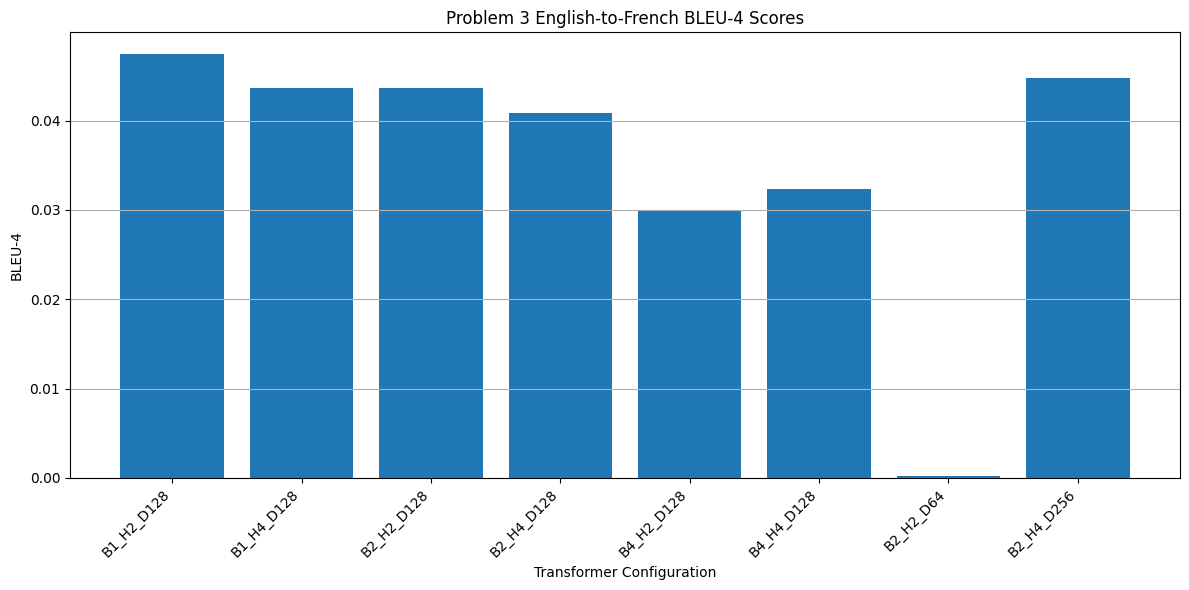

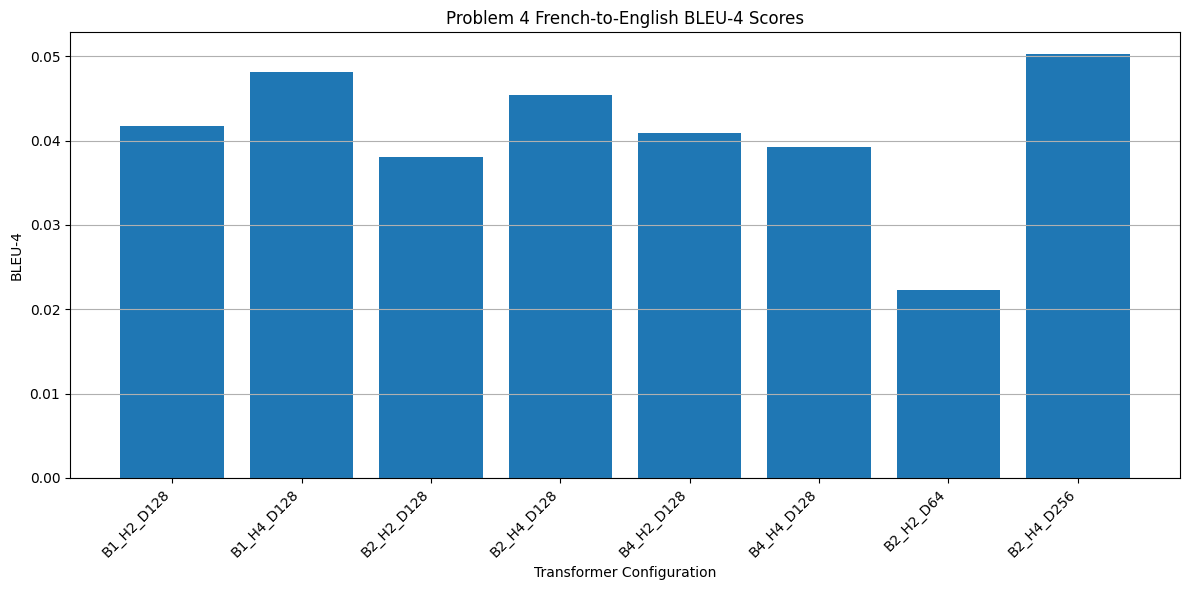

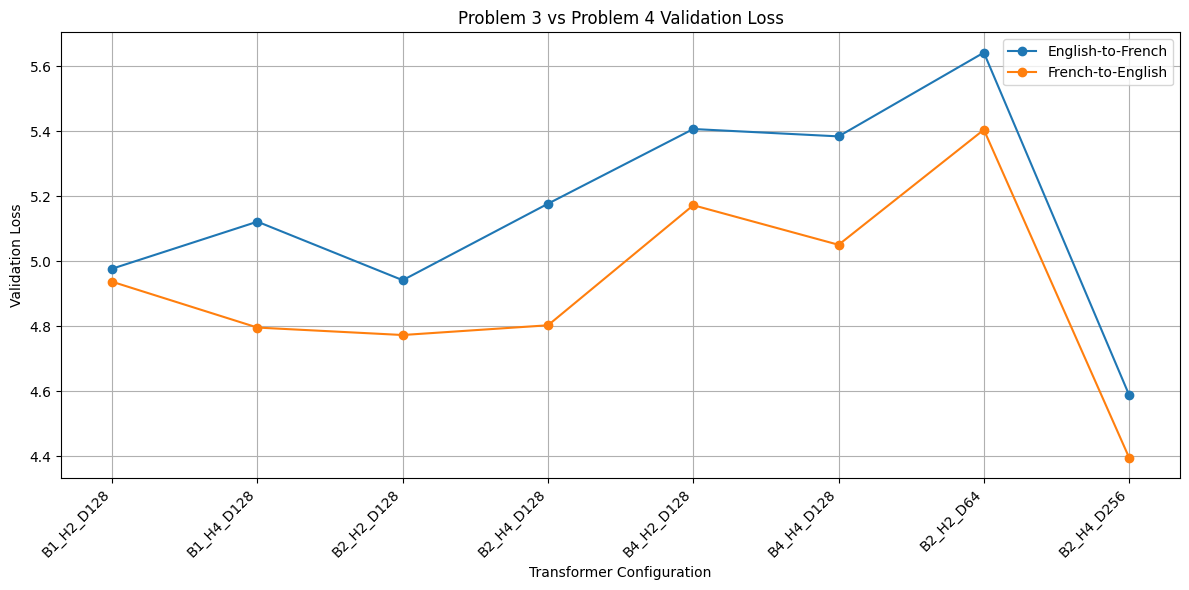

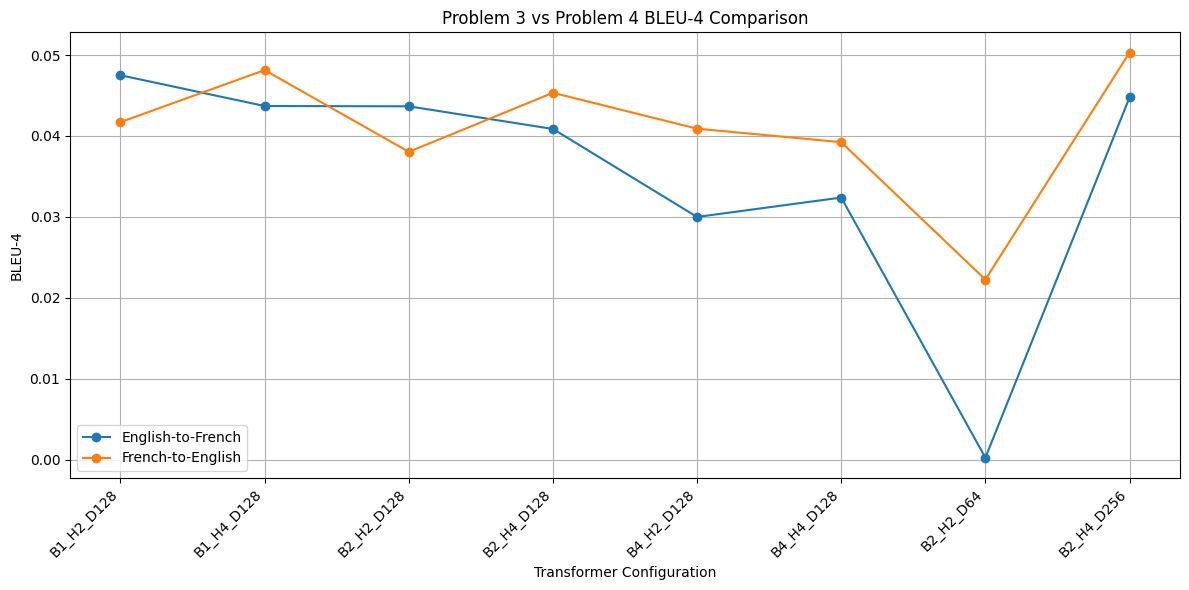

In [38]:
# =========================
# Problems 3 and 4 Plots
# =========================

plt.figure(figsize=(12, 6))
plt.bar(problem3_df["model_name"], problem3_df["bleu_4"])
plt.xlabel("Transformer Configuration")
plt.ylabel("BLEU-4")
plt.title("Problem 3 English-to-French BLEU-4 Scores")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("results/problem3_bleu_scores.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(problem4_df["model_name"], problem4_df["bleu_4"])
plt.xlabel("Transformer Configuration")
plt.ylabel("BLEU-4")
plt.title("Problem 4 French-to-English BLEU-4 Scores")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("results/problem4_bleu_scores.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(problem3_df["model_name"], problem3_df["final_val_loss"], marker="o", label="English-to-French")
plt.plot(problem4_df["model_name"], problem4_df["final_val_loss"], marker="o", label="French-to-English")
plt.xlabel("Transformer Configuration")
plt.ylabel("Validation Loss")
plt.title("Problem 3 vs Problem 4 Validation Loss")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/problem3_problem4_validation_loss_comparison.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(problem3_df["model_name"], problem3_df["bleu_4"], marker="o", label="English-to-French")
plt.plot(problem4_df["model_name"], problem4_df["bleu_4"], marker="o", label="French-to-English")
plt.xlabel("Transformer Configuration")
plt.ylabel("BLEU-4")
plt.title("Problem 3 vs Problem 4 BLEU-4 Comparison")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/problem3_problem4_bleu_comparison.png")
plt.show()

In [39]:
# =========================
# Homework 3 RNN Comparison Values
# =========================

homework3_rnn_results = pd.DataFrame([
    {
        "model": "Baseline GRU",
        "direction": "English-to-French",
        "sequence_accuracy": 0.00,
        "bleu_4": 0.0142,
        "parameters": 398566
    },
    {
        "model": "Attention GRU",
        "direction": "English-to-French",
        "sequence_accuracy": 0.00,
        "bleu_4": 0.0502,
        "parameters": 578357
    },
    {
        "model": "Baseline GRU",
        "direction": "French-to-English",
        "sequence_accuracy": 0.00,
        "bleu_4": 0.0340,
        "parameters": 384634
    },
    {
        "model": "Attention GRU",
        "direction": "French-to-English",
        "sequence_accuracy": 0.00,
        "bleu_4": 0.0552,
        "parameters": 550601
    }
])

save_dataframe(homework3_rnn_results, "homework3_rnn_comparison_values.csv")
homework3_rnn_results

Saved: results/homework3_rnn_comparison_values.csv


,model,direction,sequence_accuracy,bleu_4,parameters
0,Baseline GRU,English-to-French,0.0,0.0142,398566
1,Attention GRU,English-to-French,0.0,0.0502,578357
2,Baseline GRU,French-to-English,0.0,0.0340,384634
3,Attention GRU,French-to-English,0.0,0.0552,550601


In [40]:
# =========================
# Final Homework 4 Summary
# =========================

best_p3 = problem3_df.sort_values("bleu_4", ascending=False).iloc[0]
best_p4 = problem4_df.sort_values("bleu_4", ascending=False).iloc[0]

homework4_summary = pd.DataFrame([
    {
        "problem": "Problem 1",
        "task": "Character prediction text sequence",
        "best_model": "Transformer",
        "best_metric": problem1_df["final_val_accuracy"].max(),
        "metric_name": "Validation Accuracy"
    },
    {
        "problem": "Problem 2",
        "task": "Tiny Shakespeare character prediction",
        "best_model": "Transformer",
        "best_metric": problem2_hyper_df["final_val_accuracy"].max(),
        "metric_name": "Validation Accuracy"
    },
    {
        "problem": "Problem 3",
        "task": "English-to-French translation",
        "best_model": best_p3["model_name"],
        "best_metric": best_p3["bleu_4"],
        "metric_name": "BLEU-4"
    },
    {
        "problem": "Problem 4",
        "task": "French-to-English translation",
        "best_model": best_p4["model_name"],
        "best_metric": best_p4["bleu_4"],
        "metric_name": "BLEU-4"
    }
])

save_dataframe(homework4_summary, "homework4_summary.csv")
homework4_summary

Saved: results/homework4_summary.csv


,problem,task,best_model,best_metric,metric_name
0,Problem 1,Character prediction text sequence,Transformer,91.719521,Validation Accuracy
1,Problem 2,Tiny Shakespeare character prediction,Transformer,62.909270,Validation Accuracy
2,Problem 3,English-to-French translation,B1_H2_D128,0.047508,BLEU-4
3,Problem 4,French-to-English translation,B2_H4_D256,0.050310,BLEU-4
